In [1]:
from dataset import load_dataset
import pandas as pd
from regression.random_forest_regression import RandomForestRegressorModel
from regression.probabilistic_rf_scoring import fit_rank_pdfs_loglik,plot_ranked_pdfs,plot_pdf_with_true_target
import joblib
import numpy as np
import os
import matplotlib.pyplot as plt
plt.style.use("default")
from plot_style import set_plot_style
set_plot_style()

In [2]:
TARGET_COL = "trq_margin"
FEUTURE=["trq_measured","mgt","ias","oat","np_ng_ratio","pa"]
TRAIN_PATH_SPLIT= "../../../../data/processed/split_85_15/train_85.csv"
TEST_PATH_SPLIT= "../../../../data/processed/split_85_15/test_15.csv"
OUTPUT_PATH= "../../../../output/random_forest_regressor/model_margin/"
MODEL_PATH="random_forest_model_margin.pkl"
METRIC_TRAIN="metric_train.csv"
METRIC_TEST="metric_test.csv"

In [3]:
train_df = load_dataset(TRAIN_PATH_SPLIT)
test_df = load_dataset(TEST_PATH_SPLIT)


X_train = train_df[FEUTURE].values
y_train = train_df[TARGET_COL].values

X_test = test_df[FEUTURE].values
y_test = test_df[TARGET_COL].values

In [4]:
rf_model = RandomForestRegressorModel(
    n_estimators=500,
    min_samples_leaf=5
)
if os.path.exists(OUTPUT_PATH+MODEL_PATH):
    rf_model=joblib.load(OUTPUT_PATH+MODEL_PATH)
else:
    rf_model.fit(X_train, y_train)
    joblib.dump(rf_model, OUTPUT_PATH + MODEL_PATH)

In [7]:
metric_train=rf_model.evaluate(X_train, y_train,"train")
df_metric_train = pd.DataFrame([metric_train])
df_metric_train.to_csv(OUTPUT_PATH+METRIC_TRAIN, index=False)

metric_validate=rf_model.evaluate(X_test, y_test,"test")
df_metric_test = pd.DataFrame([metric_validate])
df_metric_test.to_csv(OUTPUT_PATH+METRIC_TEST, index=False)


Metrics on train
MAE  : 0.313244
RMSE : 0.559002
R²   : 0.998422

Metrics on test
MAE  : 0.435695
RMSE : 0.759769
R²   : 0.997081


In [7]:
row = test_df.iloc[332]
x0 = row[FEUTURE].to_numpy().reshape(1, -1)
y_true =row[TARGET_COL]
tree_preds = rf_model.predict_trees(x0)[0].astype(float)
mean=np.median(tree_preds)

In [8]:
ranking,best =  fit_rank_pdfs_loglik(tree_preds)


=== CLASSIFICA (LOG-LIKELIHOOD) ===
01) t            | loglik=-1826.21
02) logistic     | loglik=-1829.60
03) lognorm      | loglik=-1835.17
04) erlang       | loglik=-1835.61
05) gamma        | loglik=-1835.61
06) chi2         | loglik=-1836.31
07) nakagami     | loglik=-1837.07
08) beta         | loglik=-1837.22
09) norm         | loglik=-1840.02
10) laplace      | loglik=-1866.98
11) weibull_min  | loglik=-1876.92
12) gumbel_r     | loglik=-1918.25
13) cauchy       | loglik=-1995.02
14) rayleigh     | loglik=-2275.59
15) powerlaw     | loglik=-2689.48
16) uniform      | loglik=-2701.24
17) expon        | loglik=-2882.01
18) pareto       | loglik=-2882.01
19) betaprime    | loglik=-2977.95
20) f            | loglik=-3961.70


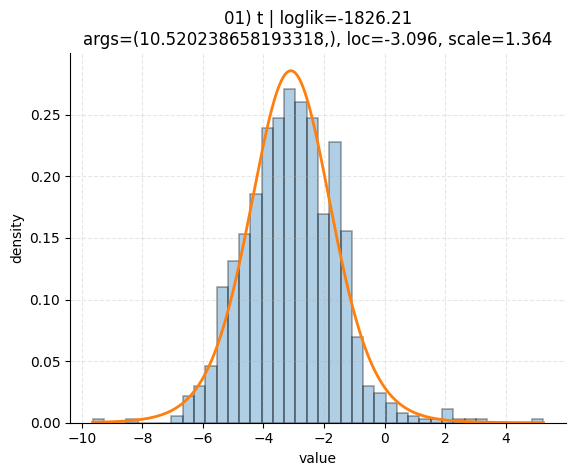

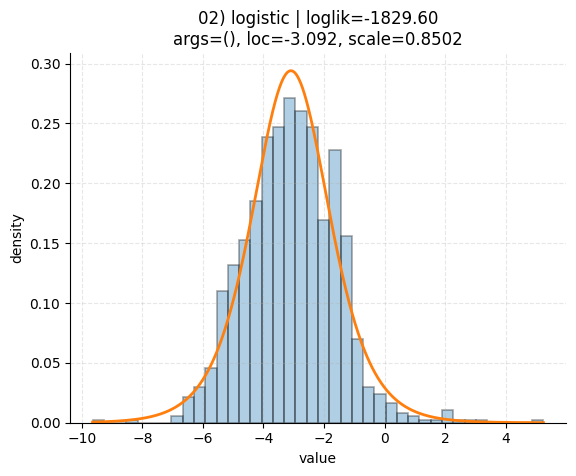

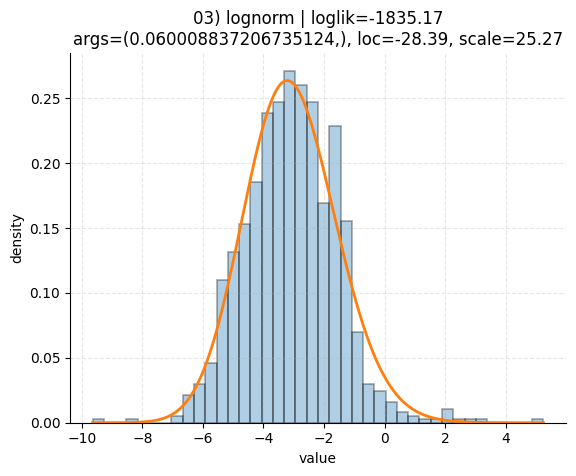

In [9]:
plot_ranked_pdfs(ranking,tree_preds)

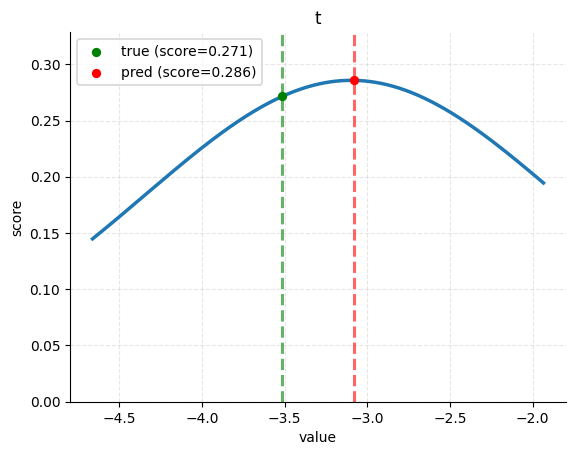

{'pdf_type': 't',
 'true_target': -3.5151855844733717,
 'prediction': -3.079540265539177,
 'score_true': 0.2713587406040549,
 'score_pred': 0.2856891439078489,
 'x_range': (-4.660931807752178, -1.9337940422603714)}

In [10]:
plot_pdf_with_true_target(best["pdf_type"],best["pdf_args"],y_true,mean)

In [21]:
from regression.probabilistic_rf_scoring import get_regression_score
from tqdm import tqdm


pdf_list = ["norm", "t", "cauchy", "laplace", "lognorm", "gamma"]

rng = np.random.default_rng(42)

rows_out = []

pbar = tqdm(range(len(test_df)), desc="Processing test set", unit="row")

for i in pbar:

    test_row = test_df.iloc[i]

    trq_measured = float(test_row["trq_measured"])
    trq_target_true = float(test_row["trq_target"])
    test_x = test_row[FEUTURE].to_frame().T


    test_y_true = (trq_measured / trq_target_true - 1.0) * 100.0


    pbar.set_postfix_str("predicting")
    target_pred = rf_model.predict_trees(x0)[0].astype(float)


    pbar.set_postfix_str("fitting pdf")
    ranking, best = fit_rank_pdfs_loglik(tree_preds, pdf_list=pdf_list)

    if best is None or best.get("pdf_args") is None:
        continue

    best_pdf = best["pdf_type"]
    best_args = best["pdf_args"]


    pbar.set_postfix_str("scoring")
    score_true = float(get_regression_score(best_pdf, best_args, float(test_y_true)))
    score_pred = float(get_regression_score(best_pdf, best_args, float(np.mean(target_pred))))

    out = test_row[FEUTURE].to_dict()
    out.update({
        "idx": i,
        "trq_target_true": trq_target_true,
        "trq_target_pred": target_pred,
        "y_true": float(test_y_true),
        "y_pred": float(np.mean(target_pred)),
        "best_pdf": best_pdf,
        "best_pdf_args": best_args,
        "best_loglik": float(best.get("loglik", np.nan)),
        "score_true": score_true,
        "score_pred": score_pred,
    })

    rows_out.append(out)

pbar.close()

df_report = pd.DataFrame(rows_out)
df_report.head()


Processing test set:   0%|          | 1/111394 [00:00<3:56:49,  7.84row/s, scoring]    


=== CLASSIFICA (LOG-LIKELIHOOD) ===
01) t            | loglik=-907.33
02) lognorm      | loglik=-917.94
03) gamma        | loglik=-918.20
04) norm         | loglik=-920.08
05) laplace      | loglik=-925.88
06) cauchy       | loglik=-988.28

=== CLASSIFICA (LOG-LIKELIHOOD) ===
01) t            | loglik=-907.33
02) lognorm      | loglik=-917.94
03) gamma        | loglik=-918.20
04) norm         | loglik=-920.08
05) laplace      | loglik=-925.88
06) cauchy       | loglik=-988.28

=== CLASSIFICA (LOG-LIKELIHOOD) ===
01) t            | loglik=-907.33
02) lognorm      | loglik=-917.94
03) gamma        | loglik=-918.20
04) norm         | loglik=-920.08
05) laplace      | loglik=-925.88
06) cauchy       | loglik=-988.28


Processing test set:   0%|          | 5/111394 [00:00<3:10:56,  9.72row/s, scoring]    


=== CLASSIFICA (LOG-LIKELIHOOD) ===
01) t            | loglik=-907.33
02) lognorm      | loglik=-917.94
03) gamma        | loglik=-918.20
04) norm         | loglik=-920.08
05) laplace      | loglik=-925.88
06) cauchy       | loglik=-988.28

=== CLASSIFICA (LOG-LIKELIHOOD) ===
01) t            | loglik=-907.33
02) lognorm      | loglik=-917.94
03) gamma        | loglik=-918.20
04) norm         | loglik=-920.08
05) laplace      | loglik=-925.88
06) cauchy       | loglik=-988.28

=== CLASSIFICA (LOG-LIKELIHOOD) ===
01) t            | loglik=-907.33
02) lognorm      | loglik=-917.94
03) gamma        | loglik=-918.20
04) norm         | loglik=-920.08
05) laplace      | loglik=-925.88
06) cauchy       | loglik=-988.28


Processing test set:   0%|          | 8/111394 [00:00<3:15:39,  9.49row/s, scoring]    

...

Processing test set:   2%|▏         | 2647/111394 [04:23<3:54:43,  7.72row/s, fitting pdf]


=== CLASSIFICA (LOG-LIKELIHOOD) ===
01) t            | loglik=-907.33
02) lognorm      | loglik=-917.94
03) gamma        | loglik=-918.20
04) norm         | loglik=-920.08
05) laplace      | loglik=-925.88
06) cauchy       | loglik=-988.28

=== CLASSIFICA (LOG-LIKELIHOOD) ===
01) t            | loglik=-907.33
02) lognorm      | loglik=-917.94
03) gamma        | loglik=-918.20
04) norm         | loglik=-920.08
05) laplace      | loglik=-925.88
06) cauchy       | loglik=-988.28

=== CLASSIFICA (LOG-LIKELIHOOD) ===
01) t            | loglik=-907.33
02) lognorm      | loglik=-917.94
03) gamma        | loglik=-918.20
04) norm         | loglik=-920.08
05) laplace      | loglik=-925.88
06) cauchy       | loglik=-988.28


Processing test set:   2%|▏         | 2648/111394 [04:23<3:00:25, 10.05row/s, scoring]    


=== CLASSIFICA (LOG-LIKELIHOOD) ===
01) t            | loglik=-907.33
02) lognorm      | loglik=-917.94
03) gamma        | loglik=-918.20
04) norm         | loglik=-920.08
05) laplace      | loglik=-925.88
06) cauchy       | loglik=-988.28


KeyboardInterrupt: 